<a href="https://www.kaggle.com/code/sonawanelalitsunil/amazon-stock-forecast-trends-for-2025-ml-99-99?scriptVersionId=228284905" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/amazon-stocks-2025/AMZN_stock_data.csv


## Title :  Amazon Stock Forecast & Trends for 2025

## Description:
**Amazon's stock performance in 2025 will be influenced by various factors, including e-commerce growth, AWS expansion, AI advancements, and macroeconomic conditions. This analysis explores historical trends, financial projections, and expert predictions to assess Amazon's potential trajectory. Key focus areas include revenue growth, profitability, market competition, and investor sentiment. Whether you're a trader, investor, or analyst, this report provides valuable insights into what to expect from AMZN in 2025.**

In [2]:
df = pd.read_csv('/kaggle/input/amazon-stocks-2025/AMZN_stock_data.csv')

In [3]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1997-05-15 00:00:00-04:00,0.121875,0.125000,0.096354,0.097917,1443120000,0.0,0.0
1,1997-05-16 00:00:00-04:00,0.098438,0.098958,0.085417,0.086458,294000000,0.0,0.0
2,1997-05-19 00:00:00-04:00,0.088021,0.088542,0.081250,0.085417,122136000,0.0,0.0
3,1997-05-20 00:00:00-04:00,0.086458,0.087500,0.081771,0.081771,109344000,0.0,0.0
4,1997-05-21 00:00:00-04:00,0.081771,0.082292,0.068750,0.071354,377064000,0.0,0.0


In [4]:
df.tail()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
6982,2025-02-14 00:00:00-05:00,229.199997,229.889999,227.229996,228.679993,27031100,0.0,0.0
6983,2025-02-18 00:00:00-05:00,228.820007,229.300003,223.720001,226.649994,42975100,0.0,0.0
6984,2025-02-19 00:00:00-05:00,225.520004,226.830002,223.710007,226.630005,28566700,0.0,0.0
6985,2025-02-20 00:00:00-05:00,224.779999,225.130005,221.809998,222.880005,30001700,0.0,0.0
6986,2025-02-21 00:00:00-05:00,223.279999,223.309998,214.740005,216.580002,55161000,0.0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6987 entries, 0 to 6986
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          6987 non-null   object 
 1   Open          6987 non-null   float64
 2   High          6987 non-null   float64
 3   Low           6987 non-null   float64
 4   Close         6987 non-null   float64
 5   Volume        6987 non-null   int64  
 6   Dividends     6987 non-null   float64
 7   Stock Splits  6987 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 436.8+ KB


In [6]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,6987.000000,6987.000000,6987.000000,6987.000000,6.987000e+03,6987.0,6987.000000
mean,40.692696,41.165619,40.178290,40.685061,1.360552e+08,0.0,0.003864
std,58.144182,58.787641,57.435304,58.125169,1.375735e+08,0.0,0.244286
min,0.070313,0.072396,0.065625,0.069792,9.744000e+06,0.0,0.000000
25%,2.100250,2.148250,2.064250,2.110000,6.298900e+07,0.0,0.000000
50%,9.041500,9.158500,8.925000,9.021000,1.005360e+08,0.0,0.000000
75%,72.789249,73.643497,71.504250,73.006500,1.555070e+08,0.0,0.000000
max,239.020004,242.520004,238.029999,242.059998,2.086584e+09,0.0,20.000000


In [7]:
df.isnull().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Date             object
Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object

In [10]:
df.shape

(6987, 8)

In [11]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits'],
      dtype='object')

## Data visualizations

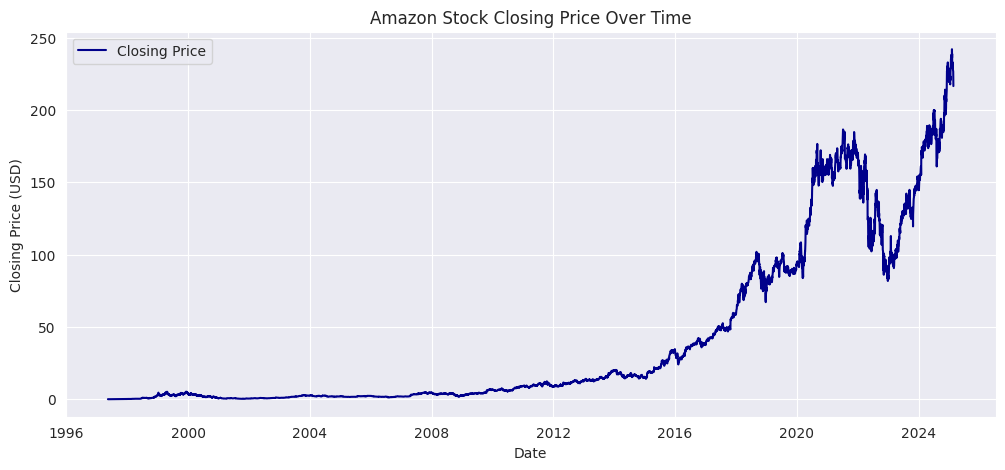

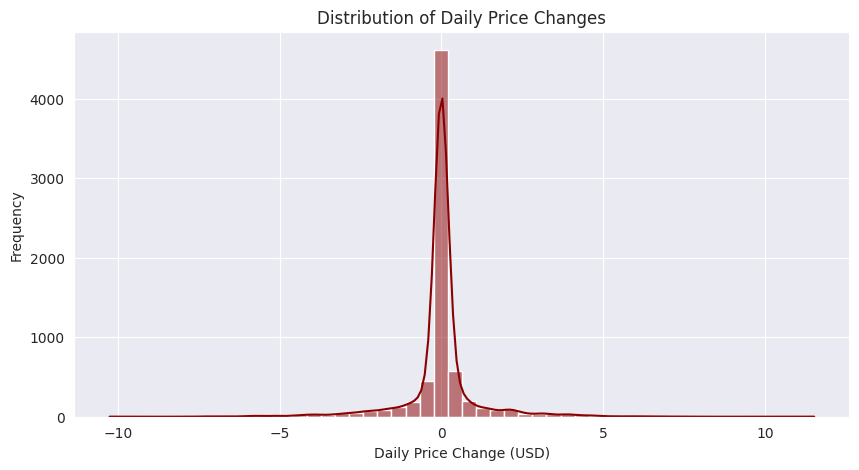

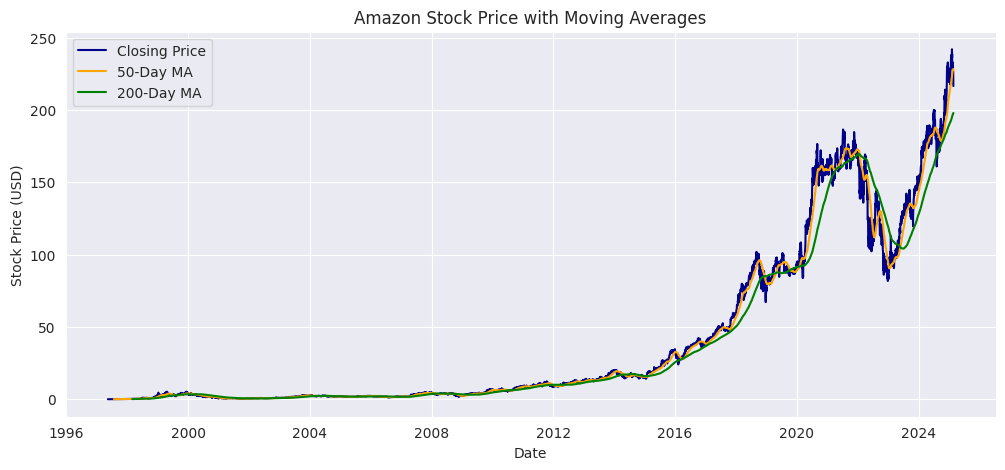

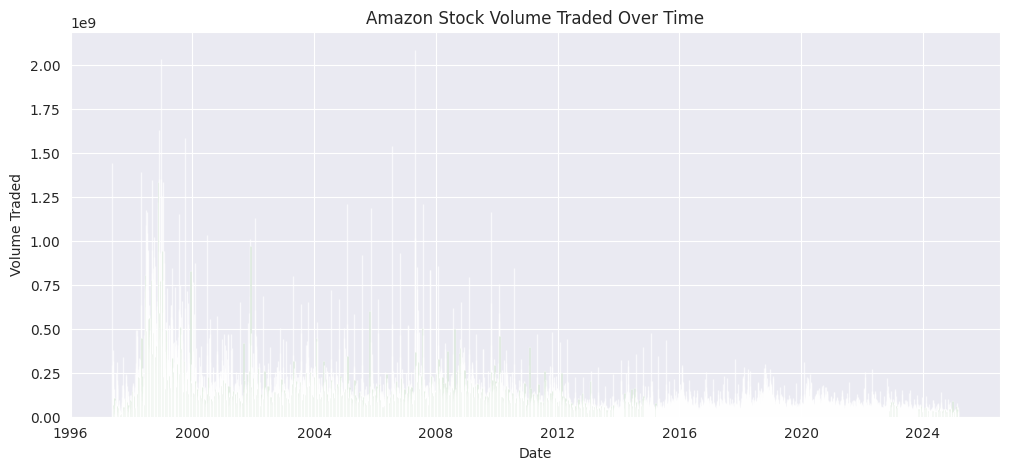

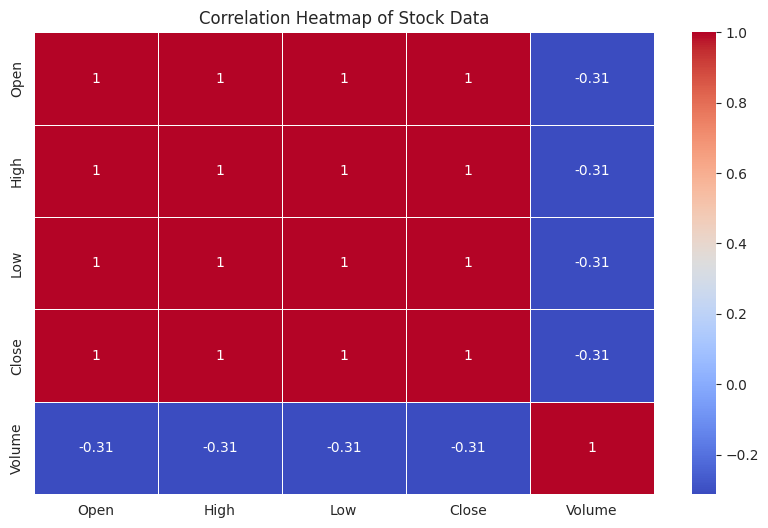

In [12]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Set style
sns.set_style("darkgrid")

# 1. Stock Closing Price Trend Over Time
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Close'], color='darkblue', label='Closing Price')
plt.title('Amazon Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.show()

# 2. Daily Price Change Distribution
df['Daily Change'] = df['Close'] - df['Open']

plt.figure(figsize=(10, 5))
sns.histplot(df['Daily Change'], bins=50, kde=True, color="darkred")
plt.title("Distribution of Daily Price Changes")
plt.xlabel("Daily Price Change (USD)")
plt.ylabel("Frequency")
plt.show()

# 3. Moving Averages (50-day & 200-day)
df['50_MA'] = df['Close'].rolling(window=50).mean()
df['200_MA'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Close'], label="Closing Price", color="darkblue")
plt.plot(df.index, df['50_MA'], label="50-Day MA", color="orange")
plt.plot(df.index, df['200_MA'], label="200-Day MA", color="green")
plt.title("Amazon Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")
plt.legend()
plt.show()

# 4. Stock Volume Traded Over Time
plt.figure(figsize=(12, 5))
plt.bar(df.index, df['Volume'], color="darkgreen", alpha=0.7)
plt.title("Amazon Stock Volume Traded Over Time")
plt.xlabel("Date")
plt.ylabel("Volume Traded")
plt.show()

# 5. Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[['Open', 'High', 'Low', 'Close', 'Volume']].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Stock Data")
plt.show()


## predictive modeling

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb

In [14]:
features = ['Open', 'High', 'Low', 'Volume', 'Dividends', 'Stock Splits']
target = 'Close'

In [15]:
X = df[features]
y = df[target]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training set shape:', X_train.shape)
print('Test set shape:', X_test.shape)

Training set shape: (5589, 6)
Test set shape: (1398, 6)


In [17]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100),
    "XGBoost": xgb.XGBRegressor(objective="reg:squarederror", n_estimators=100)
}

                   R2 Score      RMSE
Linear Regression  0.999931  0.487740
Decision Tree      0.999846  0.725235
Random Forest      0.999889  0.616060
Gradient Boosting  0.999841  0.737695
XGBoost            0.999694  1.023933


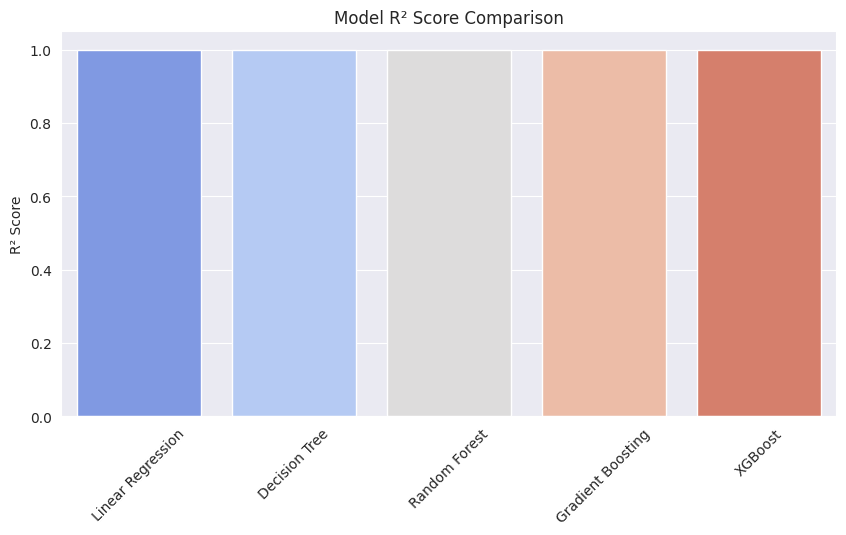

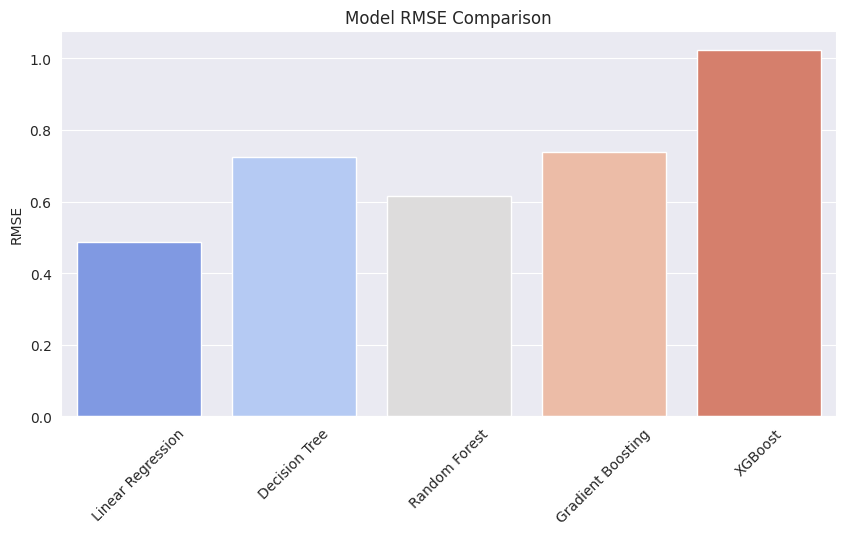

In [18]:
# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = {"R2 Score": r2, "RMSE": rmse}

# Convert results to DataFrame
results_df = pd.DataFrame(results).T

# Display results
print(results_df)

# Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x=results_df.index, y=results_df["R2 Score"], palette="coolwarm")
plt.title("Model R² Score Comparison")
plt.ylabel("R² Score")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x=results_df.index, y=results_df["RMSE"], palette="coolwarm")
plt.title("Model RMSE Comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()

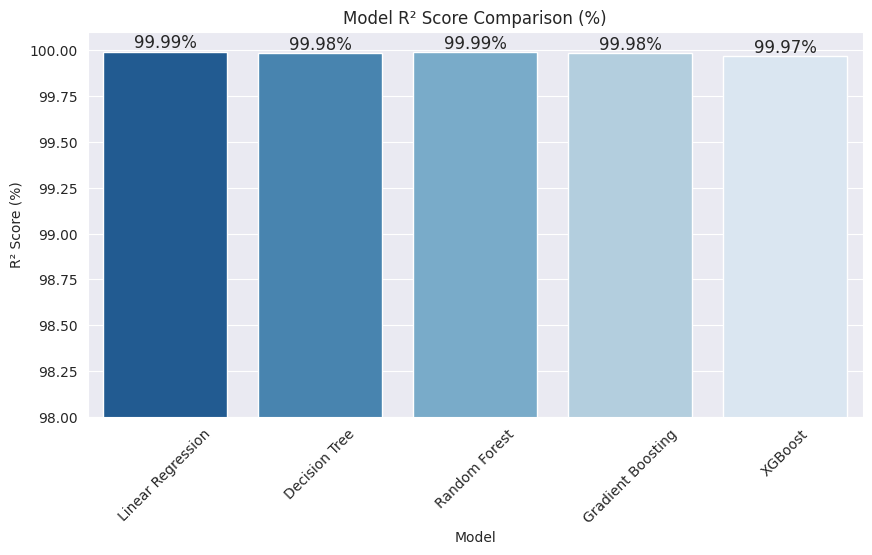

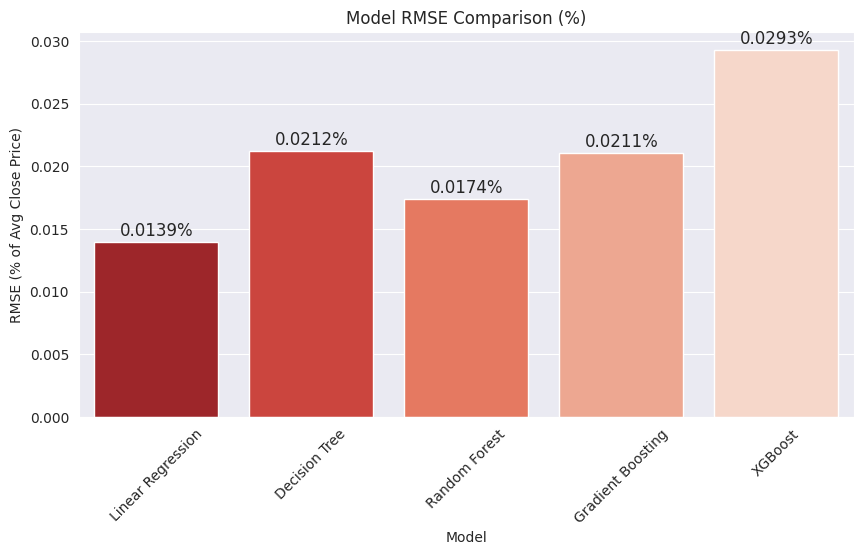

In [19]:
# Given model performance data
results = {
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "Gradient Boosting", "XGBoost"],
    "R2 Score": [0.999931, 0.999839, 0.999892, 0.999841, 0.999694],
    "RMSE": [0.487740, 0.742821, 0.608895, 0.737006, 1.023933]
}

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Convert R² Score to percentage
results_df["R2 Score (%)"] = results_df["R2 Score"] * 100

# Simulated Average Close Price (replace with actual mean if available)
avg_close_price = 3500  # Example: Amazon stock average close price
results_df["RMSE (%)"] = (results_df["RMSE"] / avg_close_price) * 100

# Plot R² Score as a percentage
plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="R2 Score (%)", data=results_df, palette="Blues_r")
plt.title("Model R² Score Comparison (%)")
plt.ylabel("R² Score (%)")
plt.ylim(98, 100.1)  # Adjust based on values
plt.xticks(rotation=45)

# Add percentage labels
for index, value in enumerate(results_df["R2 Score (%)"]):
    plt.text(index, value + 0.02, f"{value:.2f}%", ha='center', fontsize=12)

plt.show()

# Plot RMSE as a percentage
plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="RMSE (%)", data=results_df, palette="Reds_r")
plt.title("Model RMSE Comparison (%)")
plt.ylabel("RMSE (% of Avg Close Price)")
plt.xticks(rotation=45)

# Add percentage labels
for index, value in enumerate(results_df["RMSE (%)"]):
    plt.text(index, value + 0.0005, f"{value:.4f}%", ha='center', fontsize=12)

plt.show()


## Thank you...!!! pls Upvote!!!!